# **Análise experimental de algoritmos de ordenação**

> Este notebook compara empiricamente os algoritmos de ordenação do projeto, avaliando tempo de execução e uso de memória para diferentes tamanhos de entrada.

### _**Objetivo**_

_Avaliar experimentalmente algoritmos de ordenação e verificar a qualidade das recomendações produzidas pelo seletor adaptativo._

### _**Configuração do ambiente**_

Importação das bibliotecas e algoritmos utilizados durante os experimentos.

In [44]:
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd()))

from app.algoritimos.ordenacao import bubble_sort, heap_sort, insertion_sort, merge_sort, quick_sort, selection_sort
from app.utils.benchmark import Benchmark
from app.utils.gerador import gerar_aleatorio
from app.analizador.caracteristicas import AnalisadorCaracteristicas
from app.analizador.motor_decisao import MotorDecisao

### _**Geração dos datasets**_

São criados conjuntos de dados com diferentes características:

- Aleatórios
- Crescentes
- Decrescentes

In [45]:
def gerar_dados(n, tipo='aleatorio'):
    if tipo == 'aleatorio':
        return gerar_aleatorio(n)
    if tipo == 'crescente':
        return list(range(1, n + 1))
    if tipo == 'decrescente':
        return list(range(n, 0, -1))
    raise ValueError('Tipo de dado inválido')

def executar_experimento(algoritmos, tamanhos, tipo='aleatorio'):
    resultados = {nome: [] for nome in algoritmos}

    for n in tamanhos:
        dados = gerar_dados(n, tipo=tipo)
        for nome, funcao in algoritmos.items():
            medicao = Benchmark.medir(funcao, dados)
            resultados[nome].append({
                'tamanho': n,
                'tempo': medicao['tempo'],
                'memoria_pico_bytes': medicao['memoria_pico_bytes']
            })
    return resultados

algoritmos = {
    'bubble_sort': bubble_sort,
    'insertion_sort': insertion_sort,
    'selection_sort': selection_sort,
    'merge_sort': merge_sort,
    'quick_sort': quick_sort,
    'heap_sort': heap_sort,
}

tamanhos = [100, 250, 500]
padroes = ['aleatorio', 'crescente', 'decrescente']

In [46]:
def validar_recomendacao(dados, resultados):

    analisador = AnalisadorCaracteristicas(dados)
    caracteristicas = analisador.analisar()

    requisitos = {
        "quantidade_elementos": len(dados),
        "parcialmente_ordenado": caracteristicas["grau_ordenacao"] >= 70,
        "muitos_repetidos": caracteristicas["duplicatas"] >= 20,
        "estabilidade": False,
        "memoria_limitada": False,
        "operacao": "ordenar"
    }

    motor = MotorDecisao()

    recomendado, _ = motor.recomendar(
        caracteristicas,
        requisitos
    )

    ranking_real = sorted(
        resultados.items(),
        key=lambda item: item[1]
    )

    top2 = [
        ranking_real[0][0],
        ranking_real[1][0]
    ]

    return recomendado, top2

### _**Análise dos Padrões: Aleatório, Crescente e Decrescente**_

In [47]:
for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    print(f'\n===== Padrão: {padrao} =====')
    for nome, medidas in resultados.items():
        ultima = medidas[-1]
        print(f"{nome}: tamanho={ultima['tamanho']} | tempo={ultima['tempo']:.6f}s | memoria_pico={ultima['memoria_pico_bytes']} bytes")


===== Padrão: aleatorio =====
bubble_sort: tamanho=500 | tempo=0.103374s | memoria_pico=807 bytes
insertion_sort: tamanho=500 | tempo=0.046578s | memoria_pico=140 bytes
selection_sort: tamanho=500 | tempo=0.129114s | memoria_pico=236 bytes
merge_sort: tamanho=500 | tempo=0.004342s | memoria_pico=8496 bytes
quick_sort: tamanho=500 | tempo=0.008759s | memoria_pico=5456 bytes
heap_sort: tamanho=500 | tempo=0.006177s | memoria_pico=252 bytes

===== Padrão: crescente =====
bubble_sort: tamanho=500 | tempo=0.045225s | memoria_pico=236 bytes
insertion_sort: tamanho=500 | tempo=0.000900s | memoria_pico=140 bytes
selection_sort: tamanho=500 | tempo=0.064617s | memoria_pico=236 bytes
merge_sort: tamanho=500 | tempo=0.006541s | memoria_pico=8496 bytes
quick_sort: tamanho=500 | tempo=0.085606s | memoria_pico=20032 bytes
heap_sort: tamanho=500 | tempo=0.004734s | memoria_pico=252 bytes

===== Padrão: decrescente =====
bubble_sort: tamanho=500 | tempo=0.114249s | memoria_pico=836 bytes
insertion_so

### _**Tabela consolidada dos resultados**_

In [48]:
linhas = []

for nome, medidas in resultados.items():

    for m in medidas:

        linhas.append({
            "Algoritmo": nome,
            "Tamanho": m["tamanho"],
            "Tempo": m["tempo"],
            "Memória": m["memoria_pico_bytes"]
        })

df = pd.DataFrame(linhas)

df.head()

,Algoritmo,Tamanho,Tempo,Memória
0,bubble_sort,100,0.000803,112
1,bubble_sort,250,0.004532,112
2,bubble_sort,500,0.114249,836
3,insertion_sort,100,0.000432,80
4,insertion_sort,250,0.003041,991


### _**Visualização dos resultados**_

Nesta etapa são apresentados gráficos comparando:

- Tempo de execução
- Consumo de memória

_**Tempo de execução**_

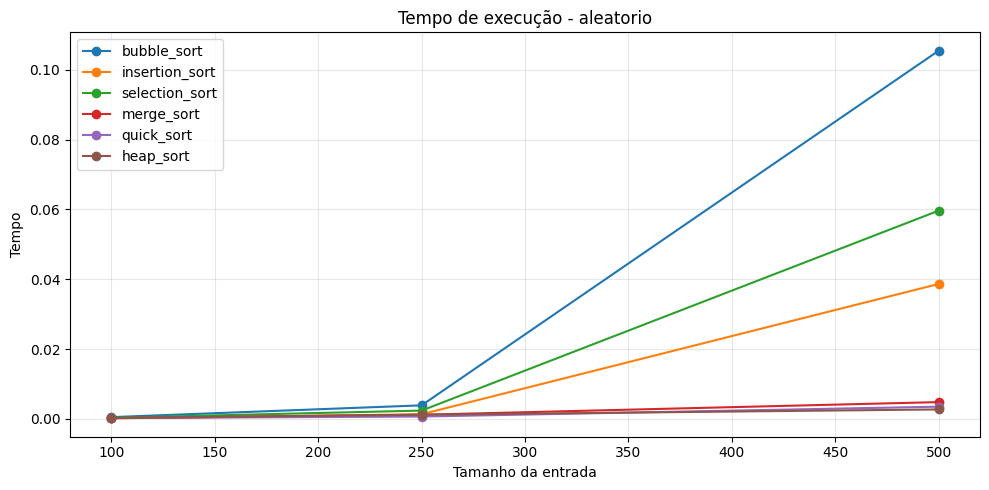

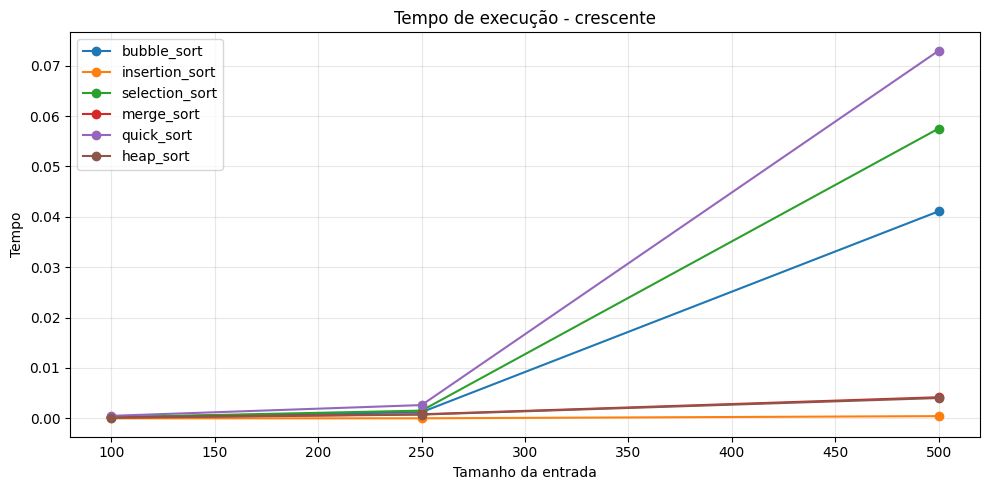

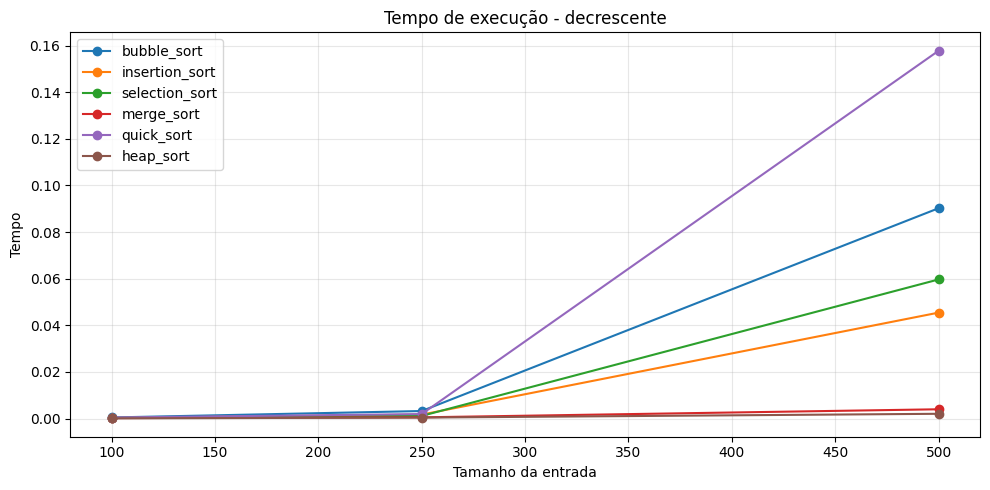

In [49]:
def plotar_resultados(resultados, metrica='tempo', titulo='Comparação experimental'):
    plt.figure(figsize=(10, 5))
    for nome, medidas in resultados.items():
        tamanhos = [m['tamanho'] for m in medidas]
        valores = [m[metrica] for m in medidas]
        plt.plot(tamanhos, valores, marker='o', label=nome)

    plt.xlabel('Tamanho da entrada')
    plt.ylabel(metrica.replace('_', ' ').title())
    plt.title(titulo)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    plotar_resultados(resultados, metrica='tempo', titulo=f'Tempo de execução - {padrao}')

_**Consumo de Memória**_

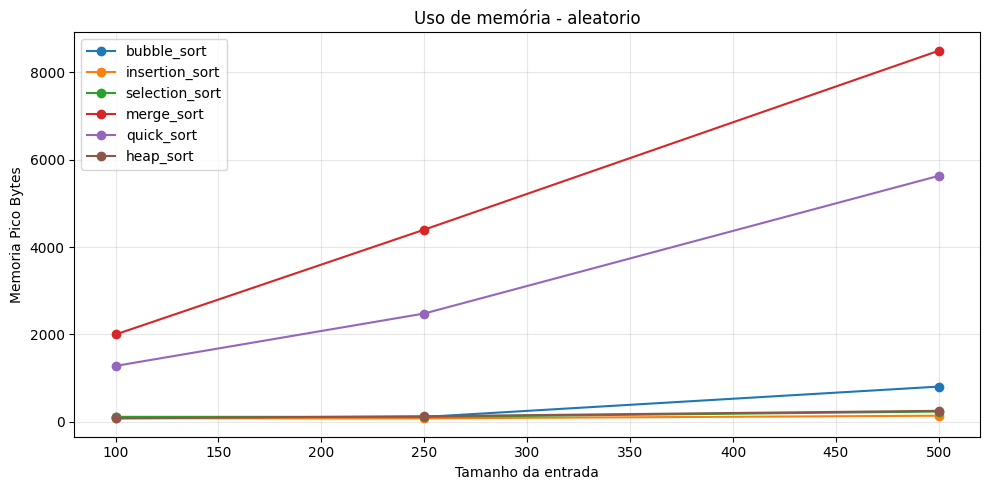

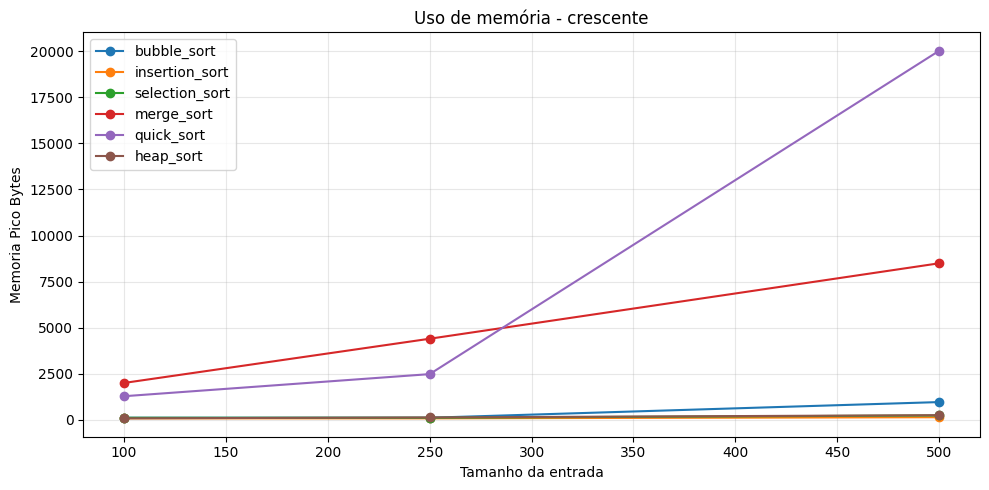

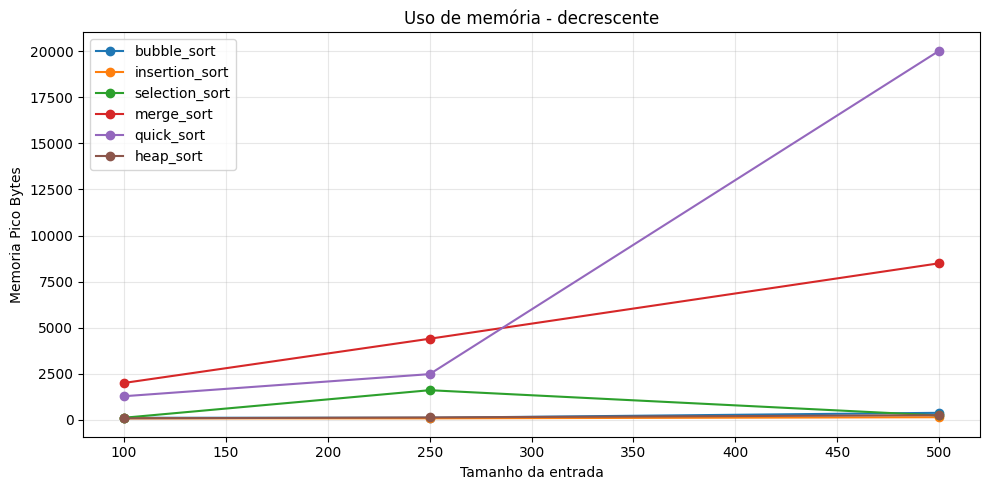

In [50]:
for padrao in padroes:
    resultados = executar_experimento(algoritmos, tamanhos, tipo=padrao)
    plotar_resultados(resultados, metrica='memoria_pico_bytes', titulo=f'Uso de memória - {padrao}')

## **Conclusão**

> - Os experimentos demonstram que algoritmos O(n²) apresentam degradação significativa conforme o tamanho da entrada aumenta.

> - Os algoritmos Merge Sort, Quick Sort e Heap Sort mantiveram desempenho superior para conjuntos grandes.

> - A validação empírica permitiu verificar se o seletor adaptativo recomenda algoritmos compatíveis com o desempenho observado experimentalmente.

## **Observações**

- Os gráficos permitem visualizar o crescimento do tempo de execução conforme o tamanho da entrada aumenta.
- Algoritmos com complexidade quadrática tendem a se deteriorar mais rapidamente em entradas maiores.
- Os resultados podem variar conforme a ordem inicial dos dados e a máquina utilizada.